Read skLearn package

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the dataset
data = load_breast_cancer()

# Feature matrix
x = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Target variable
y = pd.Series(
    (data.target == 0).astype(int),
    name="malignant"
)

print(y.value_counts())
print("Feature matrix shape:", x.shape)
print("Target shape:", y.shape)
print("Class names:", data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape: (569, 30)
Target shape: (569,)
Class names: ['malignant' 'benign']


In [2]:
# Examine the class distribution

class_counts = y.value_counts().sort_index()

class_distribution = pd.DataFrame(
    {
        "Class": data.target_names[::-1],
        "Count": class_counts.values,
        "Probability": class_counts.values / len(y)
    }
)

print(class_distribution)

       Class  Count  Probability
0     benign    357     0.627417
1  malignant    212     0.372583


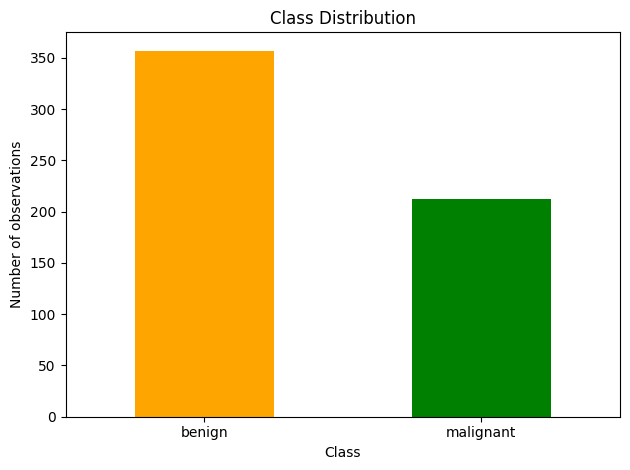

In [3]:
import matplotlib.pyplot as plt

class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    legend=False,
    color=["orange", "green"]
)

plt.ylabel("Number of observations")
plt.xlabel("Class")
plt.title("Class Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
#create training and testing samples
X_train , X_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42

    )
print("Training size= ",len(y_train))
print("Testing size= ",len(y_test))
print("Training porportions= ",len(y_train))
print(y_train.value_counts(normalize=True).sort_index())

Training size=  455
Testing size=  114
Training porportions=  455
malignant
0    0.628571
1    0.371429
Name: proportion, dtype: float64


In [5]:
from sklearn.pipeline import make_pipeline

# Train logistic regression model pipeline
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [6]:
# obtain predicted probabilities

probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[8.86409750e-01 1.13590250e-01]
 [9.00936206e-06 9.99990991e-01]
 [3.07909541e-03 9.96920905e-01]
 [9.99489866e-01 5.10134225e-04]
 [9.99939361e-01 6.06389713e-05]]


In [7]:
results = pd.DataFrame({
    "Actual_class" : y_test.values,
    "p_malignant" : probabilities[:,0] ,
    "p_benign" :  probabilities[:,1]
})
print(results.head(10))

   Actual_class   p_malignant  p_benign
0             0  8.864098e-01  0.113590
1             1  9.009362e-06  0.999991
2             1  3.079095e-03  0.996921
3             0  9.994899e-01  0.000510
4             0  9.999394e-01  0.000061
5             1  9.480883e-11  1.000000
6             1  1.536727e-09  1.000000
7             1  3.490306e-02  0.965097
8             0  6.206579e-01  0.379342
9             0  9.992406e-01  0.000759


In [16]:
print(results.columns.tolist())

results["Actual_label"] = results["Actual_class"].map({
    0: "Malignant",
    1: "Benign"
})

print(
    results[
        ["Actual_label", "p_malignant", "p_benign"]
    ].head(10)
)




['Actual_class', 'p_malignant', 'p_benign', 'Actual_label']
  Actual_label   p_malignant  p_benign
0    Malignant  8.864098e-01  0.113590
1       Benign  9.009362e-06  0.999991
2       Benign  3.079095e-03  0.996921
3    Malignant  9.994899e-01  0.000510
4    Malignant  9.999394e-01  0.000061
5       Benign  9.480883e-11  1.000000
6       Benign  1.536727e-09  1.000000
7       Benign  3.490306e-02  0.965097
8    Malignant  6.206579e-01  0.379342
9    Malignant  9.992406e-01  0.000759


In [22]:
# Use threshold to generate predictions
threshold = 0.50

results["Predicted_malignant"] = (
    results["p_malignant"] >= threshold
).astype(int)

results["Predicted label"] = results["Predicted_malignant"].map({
    1: "Malignant",
    0: "Benign"
})

print(
    results[
        ["Actual_label", "p_malignant", "Predicted label"]
    ].head(10)
)


  Actual_label   p_malignant Predicted label
0    Malignant  8.864098e-01       Malignant
1       Benign  9.009362e-06          Benign
2       Benign  3.079095e-03          Benign
3    Malignant  9.994899e-01       Malignant
4    Malignant  9.999394e-01       Malignant
5       Benign  9.480883e-11          Benign
6       Benign  1.536727e-09          Benign
7       Benign  3.490306e-02          Benign
8    Malignant  6.206579e-01       Malignant
9    Malignant  9.992406e-01       Malignant


In [23]:
#compare different threshold
for threshold in [0.3, 0.5,0.7]:
  predictions = (
      results["p_malignant"]>=threshold
  ).astype(int)
  print(
      f"Threshold : {threshold} ",
      f"Predicted malignant cases= {predictions.sum()}"
  )

Threshold : 0.3  Predicted malignant cases= 73
Threshold : 0.5  Predicted malignant cases= 72
Threshold : 0.7  Predicted malignant cases= 68


In [24]:
# construct the confusion matrix

actual_malignant = (y_test.values ==0).astype(int)

for threshold in [0.3,0.5,0.7]:
  predicted_malignant = (
      probabilities[:,0] >= threshold
  ).astype(int)

  cm = confusion_matrix(
      actual_malignant, predicted_malignant
  )
  print(f"\nThreshold = {threshold}")
  print(cm)




Threshold = 0.3
[[41  2]
 [ 0 71]]

Threshold = 0.5
[[41  2]
 [ 1 70]]

Threshold = 0.7
[[42  1]
 [ 4 67]]


In [31]:
# Verify using sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = results["Predicted_malignant"]

print("Sklearn accuracy:",
      accuracy_score(y_test, y_pred))
print("Sklearn precision:",
      precision_score(y_test, y_pred))
print("Sklearn recall:",
      recall_score(y_test, y_pred))
print("Sklearn f1 score:",
      f1_score(y_test, y_pred))





Sklearn accuracy: 0.02631578947368421
Sklearn precision: 0.027777777777777776
Sklearn recall: 0.046511627906976744
Sklearn f1 score: 0.034782608695652174


In [41]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


threshold_metrics = []

for threshold in [0.1, 0.3, 0.5, 0.7, 0.9]:

    # Generate predictions
    y_pred = (results["p_malignant"] >= threshold).astype(int)

    y_true = results["Actual_class"]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
     ).ravel()

    # Metrics
    threshold_metrics.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_metrics = pd.DataFrame(threshold_metrics)

display(threshold_metrics.round(3))


,Threshold,Accuracy,Precision,Recall,F1 Score,TN,FP,FN,TP
0,0.1,0.044,0.066,0.116,0.084,0,71,38,5
1,0.3,0.018,0.027,0.047,0.034,0,71,41,2
2,0.5,0.026,0.028,0.047,0.035,1,70,41,2
3,0.7,0.044,0.015,0.023,0.018,4,67,42,1
4,0.9,0.070,0.015,0.023,0.019,7,64,42,1
